In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle, time
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters, newton
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(newton);

from python.forces import evaluate_force 
from python.newton import build_metropolis_hessian, eval_cholesky_log_det

---

Calculating the determinant of the matrix in the Metropolis-Hastings step (implicit),
$$
A = I_N + \Delta t \beta N \nabla^2 H_N(x),
$$
where
$$
\nabla^2 H_N(x) = \begin{cases}
            -\frac{1}{N(x_k - x_{\ell})^2}, \quad &k \neq \ell,\\
            \frac{1}{2}V''(x_k) + \frac{1}{N}\sum_{j \neq k}\frac{1}{(x_k - x_{\ell})^2}, \quad &k = \ell. 
        \end{cases}
$$

First we use the Cholesky factorisation: if using $A = LL^*$, then $\log \det(A)$ can be written
$$
\det(A) = \det(LL^*) = \det(L)^2 \implies \log \det(A) = 2\log\det(L) = 2\log \prod_{i=1}^N L_{ii} = 2\sum_{j = 1}^N \log(L_{ii}) . 
$$

In [3]:
# Build the matrix using Numba, compute the determinant using Cholesky (Scipy solver for now).
N = 500; dt = 0.1; beta = 2; potential = "quadratic"; 
potential_ints = {"quadratic": 0, "quad-quartic": 1, "quartic": 2}
M = 3; x_full = random_matrix.init_gue_eigenvalues(M, N)
pot_int = potential_ints[potential]

for j in range(M):
    x = x_full[j]; v_double_prime = forces.evaluate_force(x, pot_int, 2)
    log_det = newton.cholesky_log_det(x, beta, dt, v_double_prime)
    print(log_det)

4668.569473406803
4694.601949267814
4689.120841093462


---

See the new `maila_newton_step()` in integrators.py.

In [14]:
N = 50; dt = 0.05; T = 20; M = 200;
potential_name = "quartic"; beta = 2.0;
init = random_matrix.init_quartic_eigenvalues(M, N)
total_steps = int(T/dt)
config = {"track_accepts": True, "snapshot_interval": 1}

pipe = simulate.make_maila_pipeline(N, dt, potential_name, beta)
trajectory = simulate.simulate_dbm(init, total_steps, pipe)
info = simulate.analyse_trajectory(trajectory, total_steps, **config)

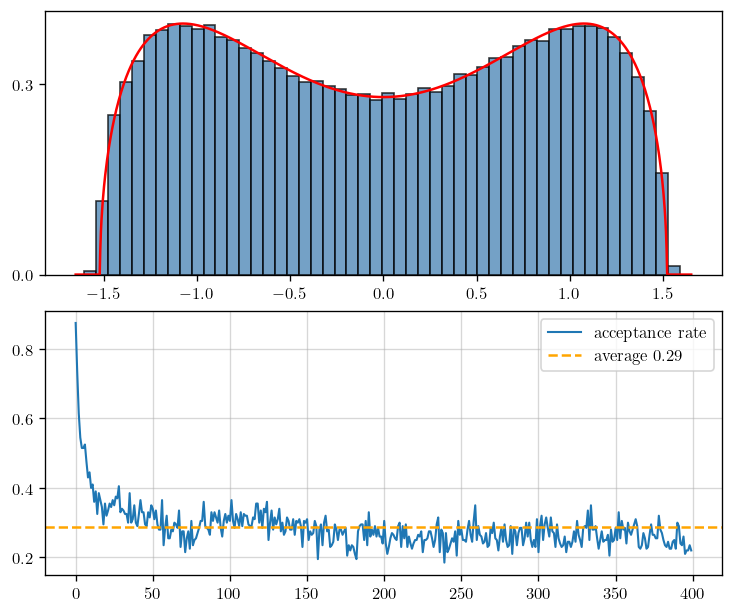

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (6, 5))
plotters.plot_hist(ax1, info["snapshots"], potential_name = potential_name, num_bins = 50)
plotters.plot_accepts(ax2, info["accepts"])

plt.show()

---
---
---

In [2]:
from numba import njit 
@njit
def slq_log_det_ratio(A_old, A_new, K = 5, m = 30):
    """ 
    Computes log(det(A_new)) - log(det(A_old)) using SLQ (stochastic Lanczos quadrature),
    see https://epubs.siam.org/doi/10.1137/16M1104974 (Algorithm 1).
    """

    N = A_old.shape[0]
    trace_difference = 0.0
    norm_z_sq = float(N) # REMOVE 

    for k in range(K):
        # Generator the shared Rademacher vector.
        z = np.sign(np.random.randn(N))
        v1 = z/np.sqrt(N) # Starting vector is unit.

        # Lanczos iteration for A_old.
        v_old = np.zeros((m + 1, N))
        v_old[0, :] = v1
        alpha_old = np.zeros(m); beta_old = np.zeros(m);

        for j in range(m): # Following notes exactly.
            w = np.dot(A_old, v_old[j])
            if (j > 0):
                w = w - beta_old[j - 1]*v_old[j - 1]

            alpha_old[j] = np.dot(v_old[j], w)
            w = w - alpha_old[j]*v_old[j] 

            # Force floating point orthoganlity.
            for i in range(j + 1):
                w = w - np.dot(v_old[i], w)*v_old[i]

            beta_j = np.linalg.norm(w)
            if (j < m - 1): # Boundary check, last values aren't in T.
                beta_old[j] = beta_j
                if (beta_j > 1e-12):
                    v_old[j + 1, :] = w/beta_j # Division by zero.

        # Construct matrix T.
        T_old = np.zeros((m, m))
        for i in range(m):
            T_old[i, i] = alpha_old[i]
            if (i < m - 1):
                T_old[i, i + 1] = beta_old[i] # Superdiagonal.
                T_old[i + 1, i] = beta_old[i] # Subdiagonal.

        # Find eigenvectors/values of T.
        eigs_old, evecs_old = np.linalg.eigh(T_old)
        approx_log_A_old = 0.0 # e_1^T ln(T) e_1, using Numba.
        for i in range(m):
            if (eigs_old[i] > 0):
                approx_log_A_old += (evecs_old[0, i]**2)*np.log(eigs_old[i])

        # Now repeat for A_new!
        v_new = np.zeros((m + 1, N))
        v_new[0, :] = v1
        alpha_new = np.zeros(m); beta_new = np.zeros(m)

        for j in range(m):
            w = np.dot(A_new, v_new[j])
            if (j > 0):
                w = w - beta_new[j - 1]*v_new[j - 1]

            alpha_new[j] = np.dot(v_new[j], w)
            w = w - alpha_new[j]*v_new[j]

            for i in range(j + 1):
                w = w - np.dot(v_new[i], w)*v_new[i] 

            beta_j = np.linalg.norm(w)
            if (j < m - 1):
                beta_new[j] = beta_j 
                if (beta_j > 1e-12):
                    v_new[j + 1, :] = w/beta_j 

        T_new = np.zeros((m, m))
        for i in range(m):
            T_new[i, i] = alpha_new[i]
            if (i < m - 1):
                T_new[i, i + 1] = beta_new[i]
                T_new[i + 1, i] = beta_new[i] 

        eigs_new, evecs_new = np.linalg.eigh(T_new)
        approx_log_A_new = 0.0 
        for i in range(m):
            if (eigs_new[i] > 0):
                approx_log_A_new += (evecs_new[0, i]**2)*np.log(eigs_new[i])

        # Constructed both, now approximation with z^T ln(A) z 
        trace_difference += float(N)*(approx_log_A_new - approx_log_A_old)

    # Outside K-loop.
    return trace_difference/K    

In [149]:
N, M = 100, 1
beta = 2.0; dt = 1/N
noise_scale = np.sqrt(2.0*dt/(beta*N))

x = random_matrix.init_quartic_eigenvalues(M, N)
y, _, _ = integrators.implicit_newton_step(x, dt, 2, noise_scale)
x = x.flatten(); y = y.flatten()

v_double_prime_x = forces.evaluate_force(x, 2, 2)
v_double_prime_y = forces.evaluate_force(y, 2, 2)
A_x = newton.build_metropolis_hessian(x, beta, dt, v_double_prime_x)
A_y = newton.build_metropolis_hessian(y, beta, dt, v_double_prime_y)

ratio_cholesky = newton.eval_cholesky_log_det(A_y) - newton.eval_cholesky_log_det(A_x)
ratio_slq = slq_log_det_ratio(A_x, A_y, K = 50, m = 50)

ratio_cholesky, ratio_slq

(6.9115210039209956, 6.992151908901308)

---

Experiment to see when the $\mathcal{O}(N^2)$ beats the Cholesky.

In [3]:
def cholesky_vs_slq(N_values, dt_values, M = 5, K = 10, m = 30, beta = 2.0):
    """ 
    Copy the FMM vs direct experiment, still using clock time.
    """

    cholesky_times = np.zeros_like(N_values, dtype = float)
    slq_times = np.zeros_like(N_values, dtype = float)
    ratio_errors = np.zeros_like(N_values, dtype = float)

    # Numba compiling warm up.
    dt_warm = 0.05
    x_warm = np.linspace(-1, 1, 50); y_warm = x_warm + 1e-4*np.random.randn(50)
    v_dp = evaluate_force(x_warm, 2, 2)
    
    A_x_warm = build_metropolis_hessian(x_warm, beta, dt_warm, v_dp)
    A_y_warm = build_metropolis_hessian(y_warm, beta, dt_warm, v_dp)
    _ = eval_cholesky_log_det(A_x_warm); _ = slq_log_det_ratio(A_x_warm, A_y_warm, K = K, m = m)

    print("Numba compilation finished.")
    for j, (N, dt) in enumerate(zip(N_values, dt_values)):
        clear_output(wait = True)
        print(f"On N = {N}.")
        
        noise_scale = np.sqrt(2.0*dt/(beta*N))
        init = random_matrix.init_quartic_eigenvalues(M, N)
        step, _, _ = integrators.implicit_newton_step(init, dt, 2, noise_scale)
        
        cholesky_time = 0.0; slq_time = 0.0;
        ratio_error = 0.0;

        for trial in range(M):
            x = init[trial, :]
            y = step[trial, :]

            v_dp_x = evaluate_force(x, 2, 2); v_dp_y = evaluate_force(y, 2, 2)
            A_x = build_metropolis_hessian(x, beta, dt, v_dp_x)
            A_y = build_metropolis_hessian(y, beta, dt, v_dp_y)

            # Time Cholesky.
            start_cholesky = time.perf_counter()
            ratio_cholesky = eval_cholesky_log_det(A_y) - eval_cholesky_log_det(A_x)
            end_cholesky = time.perf_counter()

            # Time SLQ.
            start_slq = time.perf_counter()
            ratio_slq = slq_log_det_ratio(A_x, A_y, K = K, m = m)
            end_slq = time.perf_counter()

            cholesky_time += end_cholesky - start_cholesky
            slq_time += end_slq - start_slq 
            ratio_error += np.abs(ratio_cholesky - ratio_slq)

        # End of trial loop: average. 
        cholesky_times[j] = cholesky_time/M 
        slq_times[j] = slq_time/M 
        ratio_errors[j] = ratio_error/M 


    return cholesky_times, slq_times, ratio_errors

# ====================================================

---

In [ ]:
def plot_cholesky_vs_slq(N_values, cholesky_times, slq_times, errs):
    fig, axes = plt.subplots(1, 2, figsize = (12, 3))
    ax1, ax2 = axes 

    ax1.set_xlabel(r"Matrix Dimension $N$")
    ax1.set_ylabel("Clock Time (s)")
    ax1.loglog(N_values, cholesky_times, marker = 'x', label = "cholesky")
    ax1.loglog(N_values, slq_times, marker = 'x', label = "slq")

    ax2.plot(N_values, [err/N for err, N in zip(errs, N_values)], label = "errors")
    ax2.set_xlabel(r"Matrix Dimension $N$")

    for ax in axes:
        ax.legend()

    plt.show()

---
---
---

Quick Cholesky vs. SLQ experiments.

In [5]:
N_range = np.logspace(np.log10(100), np.log10(2000), 10, dtype = int)
dts = [1/N for N in N_range]
c_times, slq_times, errs = cholesky_vs_slq(N_range, dts, M = 20)

On N = 2000.


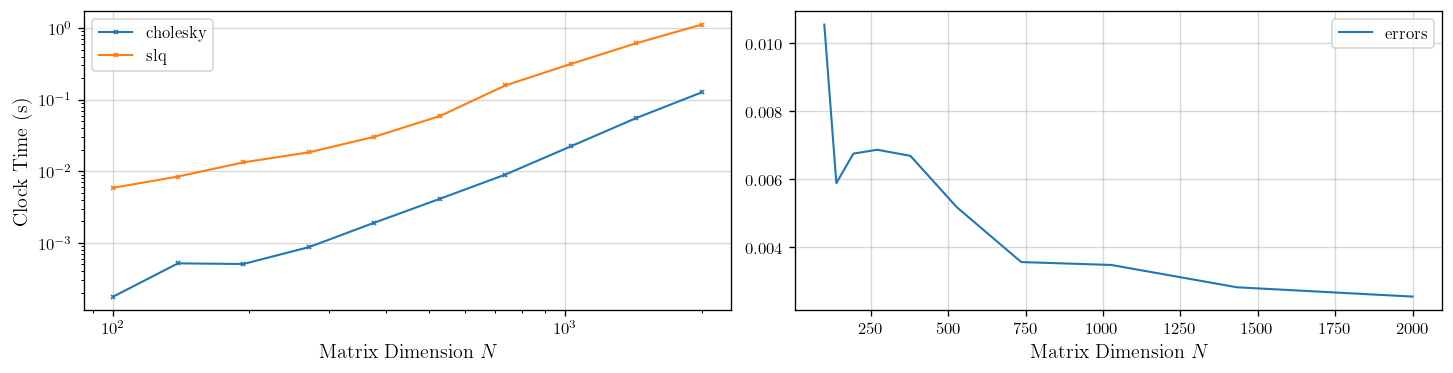

array([0.000178  , 0.00051842, 0.00050766, 0.00087415, 0.00191673])

In [ ]:
plot_cholesky_vs_slq(N_range, c_times, slq_times, errs)

In [14]:
last_c_times = c_times[-5:]; last_slq_times = slq_times[-5:]
c_slope, c_intercept = np.polyfit(np.log10(N_range[-5:]), np.log10(last_c_times), deg = 1)
slq_slope, slq_intercept = np.polyfit(np.log10(N_range[-5:]), np.log10(last_slq_times), deg = 1)

c_slope, slq_slope

(np.float64(2.5987331638331423), np.float64(2.1714136926909298))